# <span style='color:#009999'> <span style='font-family:serif'> <font size="15"> **LLC4320 surface and subsampled 3D variable data access demonstration using `xarray`**
 
    
    
<font size="3"> This notebook demonstrates easy, quick access to surface (2D) LLC4320 variables in `zarr` format, available on Johns Hopkins University's SciServer/Grendel domain.
    
<font size="3"> It also demonstrates easy, quick access to 3D LLC4320 variables that have been subsampled in the vertical direction.
    
<font size="3"> The entire LLC4320 dataset, including all the vertical levels for the 3D variables and all the 2D variables, can be accessed using the [`LLC4320_access_demonstration.ipynb`](https://github.com/hainegroup/Poseidon-share/blob/main/LLC4320_access_demonstration.ipynb) notebook.
    

    
<font size="3"> Wenrui Jiang June '25


In [1]:
import xarray as xr
import zarr
import dask

In [2]:
zarr.__version__

'2.13.3'

<span style='color:#0066cc'><font size="5"> **See the list of surface variables here:**

In [3]:
varlist2 = ['Eta','KPPhbl','PhiBot','SIarea','SIheff',
           'SIhsalt','SIhsnow','SIuice','SIvice','oceFWflx',
           'oceQnet','oceQsw','oceSflux','oceTAUX','oceTAUY']
path_2d = '/home/idies/workspace/poseidon_ceph/LLC4320_2d/'

<span style='color:#0066cc'><font size="5"> **See the list of subsampled 3D variables here:**


The subsampling is in the vertical direction: Only 12 select vertical levels are stored in the `LLC4320_subsample` dataset for analyses that don't require all 90 vertical levels. To get all 90 vertical levels, see: [`LLC4320_access_demonstration.ipynb`](https://github.com/hainegroup/Poseidon-share/blob/main/LLC4320_access_demonstration.ipynb).

In [4]:
varlist3 = ['U','V','W','Theta','Salt']
path_sub = '/home/idies/workspace/poseidon_ceph/LLC4320_subsample/'

In [5]:
%%time
files = [path_sub+var+'.zarr' for var in varlist3]+[path_2d+var+'.zarr' for var in varlist2]
datasets = [xr.open_zarr(file) for file in files]

CPU times: user 256 ms, sys: 31.1 ms, total: 287 ms
Wall time: 2.8 s


<span style='color:#0066cc'><font size="5"> **Concatenate into a single xarray dataset**

In [6]:
%%time
ds = xr.merge(datasets)

CPU times: user 9.97 ms, sys: 1.7 ms, total: 11.7 ms
Wall time: 10.9 ms


In [7]:
%%time
for var in ds.data_vars:
    isymbol = 'i'
    jsymbol = 'j'
    ksymbol = 'k'
    if var in ['U','SIuice','oceTAUX']:
        isymbol = 'i_g'
    elif var in ['V','SIvice','oceTAUY']:
        jsymbol = 'j_g'
    elif var in ['W']:
        ksymbol = 'k_l'
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        if ksymbol in ds[var].dims:
            ds[var] = xr.DataArray(ds[var].data.reshape(-1,12,13,4320,4320)[:len(ds.time)], dims = ('time',ksymbol,'face',jsymbol,isymbol))
        else:
            ds[var] = xr.DataArray(ds[var].data.reshape(-1,13,4320,4320)[:len(ds.time)], dims = ('time','face',jsymbol,isymbol))

CPU times: user 3.24 s, sys: 213 ms, total: 3.45 s
Wall time: 3.49 s


<span style='color:#0066cc'><font size="5"> **Load the LLC4320 grid information**

In [8]:
%%time
import numpy as np
subsample = '1 9 17 25 33 41 49 57 65 73 81 89'
izs = np.array([int(i) for i in subsample.split(' ')])-1

ds_grid = xr.open_zarr('/home/idies/workspace/poseidon_ceph/LLC4320/').isel(k = izs,k_l = izs,k_u = izs,k_p1 = izs)
new_k = np.arange(len(izs))
ds_grid = ds_grid.assign_coords(k    = new_k)
ds_grid = ds_grid.assign_coords(k_l  = new_k)
ds_grid = ds_grid.assign_coords(k_u  = new_k)
ds_grid = ds_grid.assign_coords(k_p1 = new_k)

ds = xr.merge([ds,ds_grid])

CPU times: user 44.8 ms, sys: 1.76 ms, total: 46.6 ms
Wall time: 47.8 ms


<span style='color:#0066cc'><font size="5">**Some plotting examples**

CPU times: user 1.26 s, sys: 355 ms, total: 1.62 s
Wall time: 1.64 s


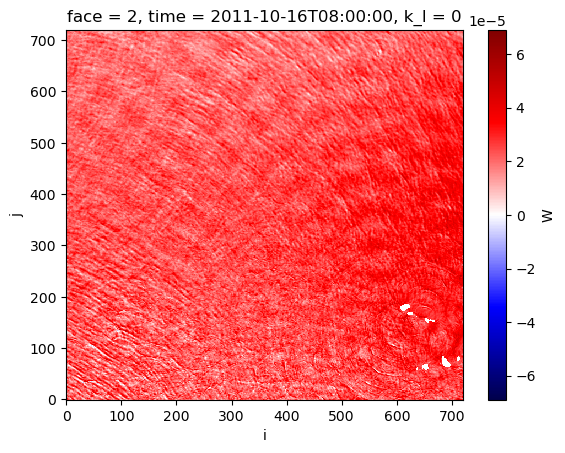

In [9]:
%%time
ds['W'].isel(time = 800,k_l = 0,face=2, i=slice(0, 720), j=slice(0, 720)).plot(cmap='seismic');

CPU times: user 1.02 s, sys: 428 ms, total: 1.44 s
Wall time: 1.45 s


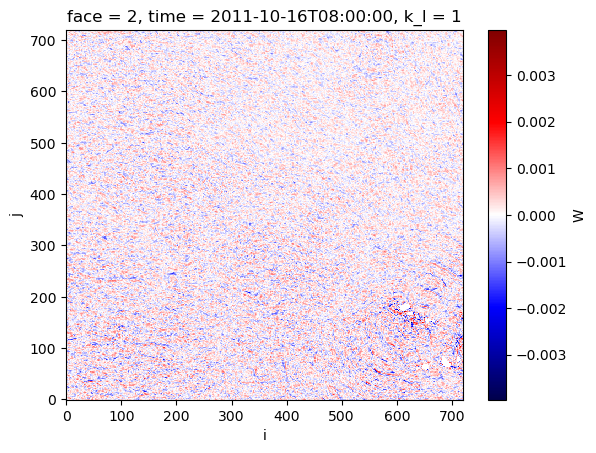

In [10]:
%%time
ds['W'].isel(time = 800,k_l = 1,face=2, i=slice(0, 720), j=slice(0, 720)).plot(cmap='seismic');

CPU times: user 917 ms, sys: 254 ms, total: 1.17 s
Wall time: 1.18 s


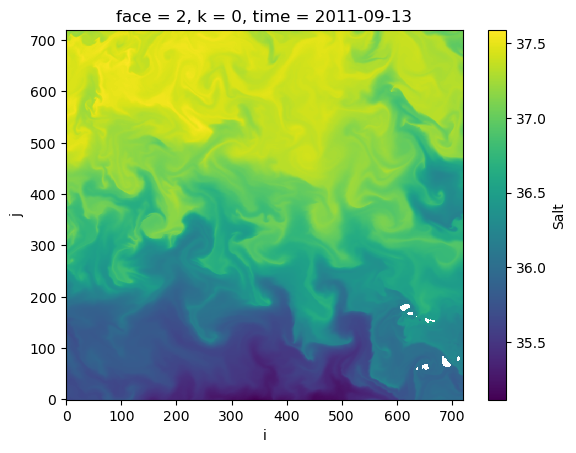

In [11]:
%%time
ds['Salt'].isel(time = 0,k = 0,face=2, i=slice(0, 720), j=slice(0, 720)).plot();

CPU times: user 815 ms, sys: 354 ms, total: 1.17 s
Wall time: 1.19 s


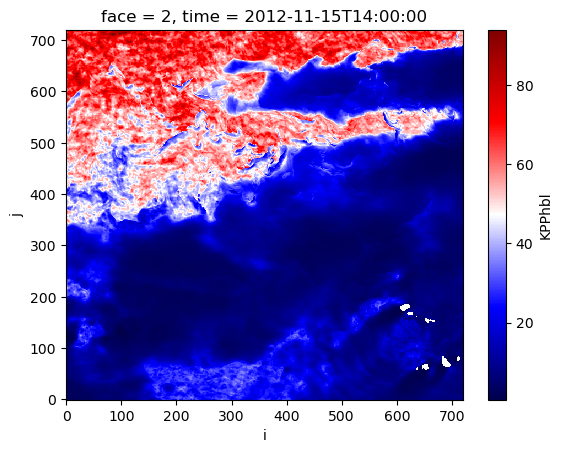

In [12]:
%%time
ds['KPPhbl'].isel(time = -1,face=2, i=slice(0, 720), j=slice(0, 720)).plot(cmap='seismic');